# FPL Player Points Predictor

**CS-UY 4563**

**Dataset**: https://github.com/vaastav/Fantasy-Premier-League, seasons 21/22 through 23/24.

The prediction task of this project is to predict a player's 'total_points' in an upcoming gameweek using only pre-kickoff information. This means that same-gameweek statistics cannot be used as features; all features are known before kickoff or lagged from prior gameweeks (e.g. rolling averages).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)

df = pd.read_csv(Path("data/processed/fpl_modeling_data.csv"))
print(f"Dataset: {df.shape[0]:,} rows * {df.shape[1]} cols")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Gameweeks per season: {df.groupby('season')['GW'].nunique().to_dict()}")

Dataset: 74,477 rows * 51 cols
Seasons: ['2021-22', '2022-23', '2023-24']
Gameweeks per season: {'2021-22': 37, '2022-23': 36, '2023-24': 37}


### Feature Exploration/Analysis

In [4]:
ID_COLS = ["name", "season", "GW", "player_season", "team", "position"]
TARGET = "total_points"
FEATURE_COLS = [c for c in df.columns if c not in ID_COLS + [TARGET]]

We notice that our target variable is very heavily right-skewed and zero-inflated. This will likely require further preprocessing on the data as this likely hurts a model's performance.

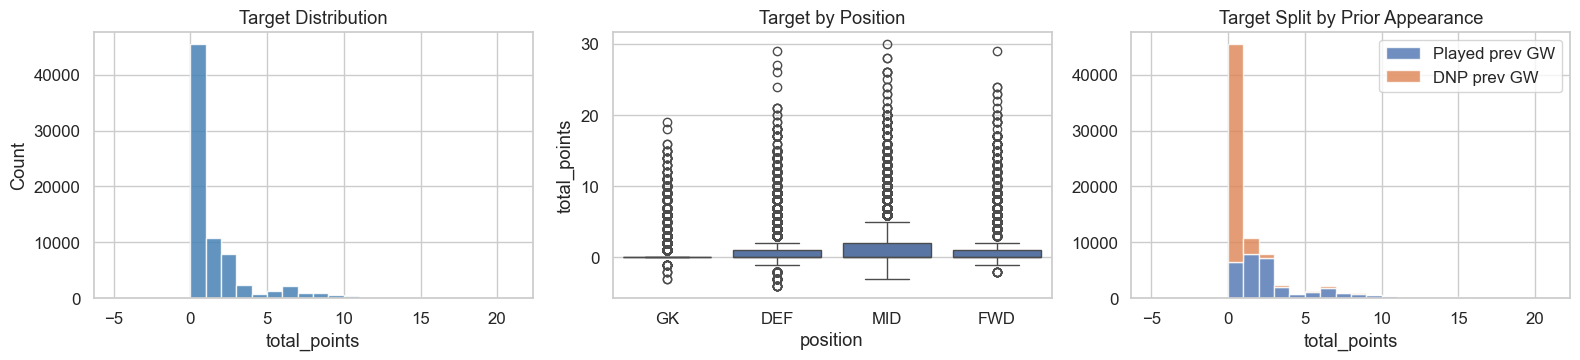

Mean: 1.23  -  Median: 0  -  Std: 2.51
Zero-point rows: 61.0%
Rows <= 2 points: 86.4%


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# overall distribution
axes[0].hist(df[TARGET], bins=range(-5, 22), edgecolor="white", alpha=0.85, color="steelblue")
axes[0].set_xlabel("total_points")
axes[0].set_ylabel("Count")
axes[0].set_title("Target Distribution")

# by position
pos_order = ["GK", "DEF", "MID", "FWD"]
sns.boxplot(data=df, x="position", y=TARGET, order=pos_order, ax=axes[1])
axes[1].set_title("Target by Position")
axes[1].set_ylabel("total_points")

# played vs didn't play
played = df[df["minutes_lag1"] > 0][TARGET]
didnt = df[df["minutes_lag1"] == 0][TARGET]
axes[2].hist([played, didnt], bins=range(-5, 22), label=["Played prev GW", "DNP prev GW"],
             edgecolor="white", alpha=0.8, stacked=True)
axes[2].legend()
axes[2].set_xlabel("total_points")
axes[2].set_title("Target Split by Prior Appearance")

plt.suptitle("", y=0)
plt.tight_layout()
plt.show()

print(f"Mean: {df[TARGET].mean():.2f}  -  Median: {df[TARGET].median():.0f}  -  Std: {df[TARGET].std():.2f}")
print(f"Zero-point rows: {(df[TARGET] == 0).mean()*100:.1f}%")
print(f"Rows <= 2 points: {(df[TARGET] <= 2).mean()*100:.1f}%")

Next we observe some of the distributions of the key features we engineered (i.e. the lagging indicators).


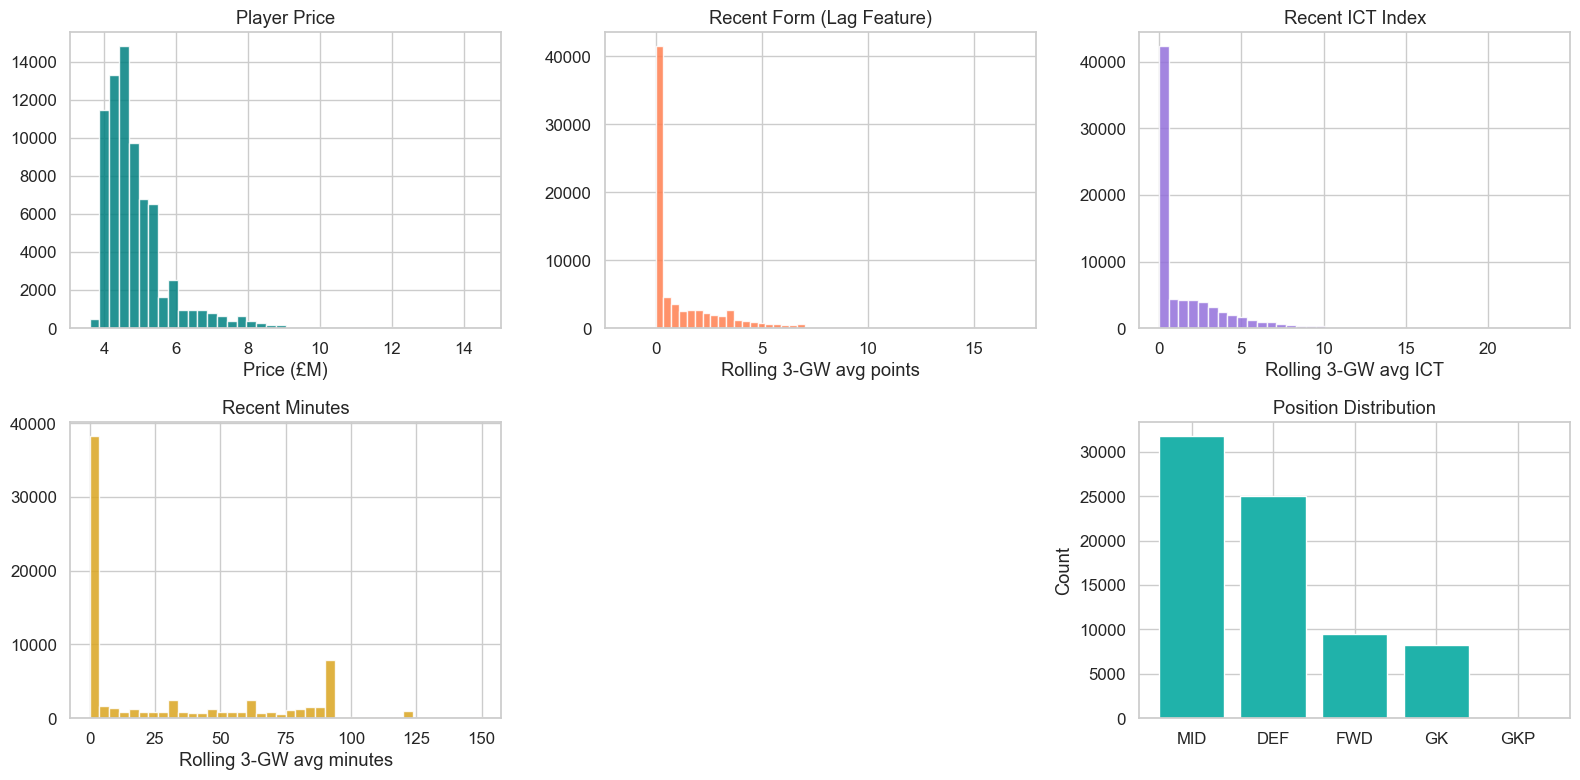

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(df["value"] / 10, bins=40, edgecolor="white", alpha=0.85, color="teal")
axes[0, 0].set_xlabel("Price (£M)")
axes[0, 0].set_title("Player Price")

axes[0, 1].hist(df["total_points_roll3"].dropna(), bins=50, edgecolor="white", alpha=0.85, color="coral")
axes[0, 1].set_xlabel("Rolling 3-GW avg points")
axes[0, 1].set_title("Recent Form (Lag Feature)")

axes[0, 2].hist(df["ict_index_roll3"].dropna().clip(0, 30), bins=40, edgecolor="white", alpha=0.85, color="mediumpurple")
axes[0, 2].set_xlabel("Rolling 3-GW avg ICT")
axes[0, 2].set_title("Recent ICT Index")

axes[1, 0].hist(df["minutes_roll3"].dropna(), bins=40, edgecolor="white", alpha=0.85, color="goldenrod")
axes[1, 0].set_xlabel("Rolling 3-GW avg minutes")
axes[1, 0].set_title("Recent Minutes")


pos_counts = df["position"].value_counts()
axes[1, 2].bar(pos_counts.index, pos_counts.values, color="lightseagreen", edgecolor="white")
axes[1, 2].set_ylabel("Count")
axes[1, 2].set_title("Position Distribution")

axes[1, 1].axis("off")
plt.tight_layout()
plt.show()

Next we observe the feature-target relationship and the highest correlations, then we observe feature-feature correlations which seem to imply that PCA might be a good tool to use in the context of this project.

In [51]:
# correlations of all features with the target
feat_corr = df[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print("Top 10 features by correlation with the target:")
feat_corr.abs().sort_values(ascending=False).head(10).round(4)

Top 10 features by correlation with the target:


xP                    0.7323
minutes_roll3         0.4892
minutes_lag1          0.4781
ict_index_roll3       0.4682
bps_roll3             0.4648
total_points_roll3    0.4582
influence_roll3       0.4491
ict_index_lag1        0.4176
bps_lag1              0.4085
influence_lag1        0.3843
Name: total_points, dtype: float64

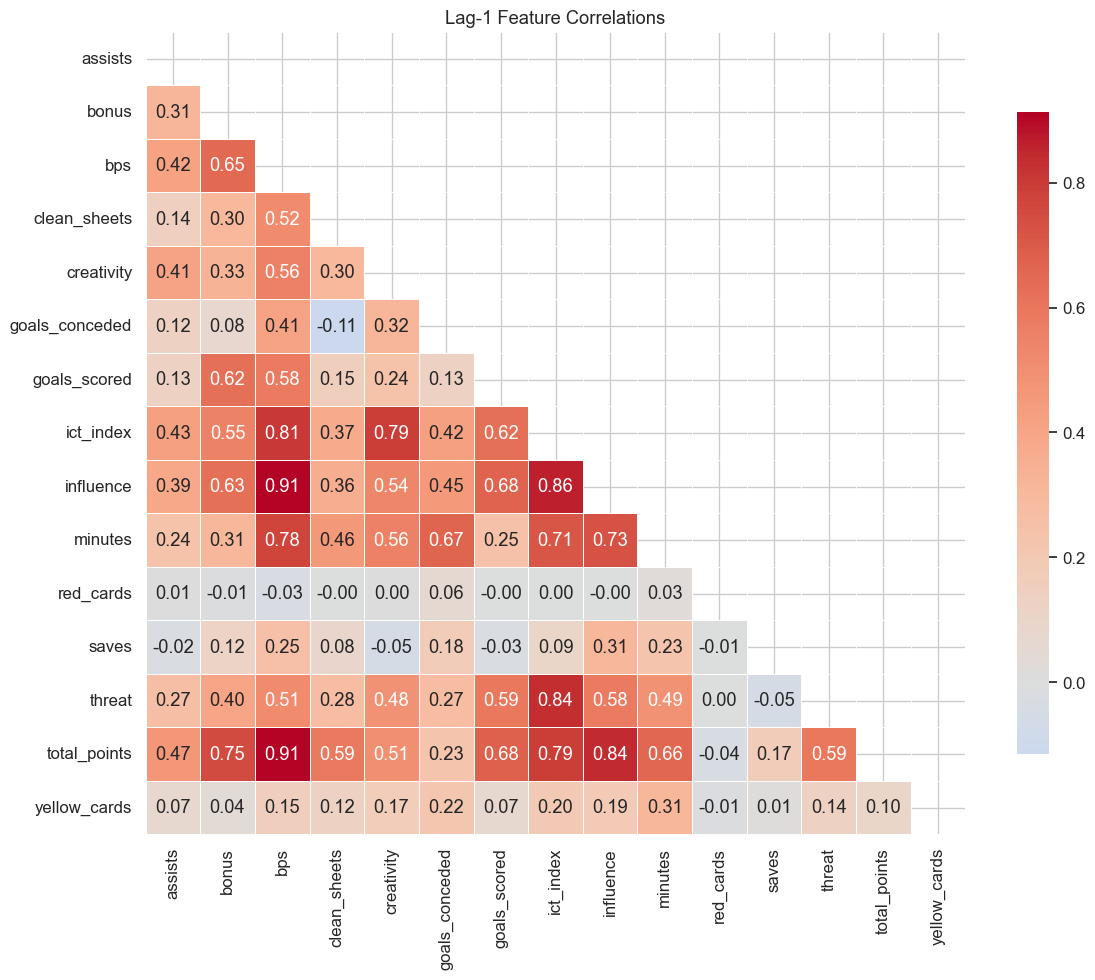

In [9]:
# focus on the lag1 features to keep the heatmap readable
lag1_cols = sorted([c for c in FEATURE_COLS if c.endswith("_lag1")])
corr_matrix = df[lag1_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
            xticklabels=[c.replace("_lag1", "") for c in lag1_cols],
            yticklabels=[c.replace("_lag1", "") for c in lag1_cols])
ax.set_title("Lag-1 Feature Correlations")
plt.tight_layout()
plt.show()

*Notes on preprocessing (not final) and data issues found*

The main "preprocessing" done for now involves having cleaned the data so that the dataset was cummulative of all three seasons, then engineering our lagging/rolling indicators (lag1 and lag3), and aggregating double gameweeks by summing performance stats.

Some notable issues were the massive amounts of raw observations which had 0 total points and the season-specific columns (which we simply pruned to have feature consistency across all seasons).

## Baseline models

Next we will implement some simple models with the current state of the data so that we can have some easy benchmarks to compare future implementations against. We also have a benchmark provided by the dataset (xP, or expected points) which will be our general benchmark to beat by a large amount.

In [39]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# time-aware split
train_mask = df["season"].isin(["2021-22", "2022-23"])
val_mask = df["season"] == "2023-24"

X_train = df.loc[train_mask, FEATURE_COLS].values
y_train = df.loc[train_mask, TARGET].values
X_val = df.loc[val_mask, FEATURE_COLS].values
y_val = df.loc[val_mask, TARGET].values

print(f"Train: {len(y_train):,} rows (21/22 + 22/23)")
print(f"Val:   {len(y_val):,} rows (23/24)")

Train: 46,604 rows (21/22 + 22/23)
Val:   27,873 rows (23/24)


In [40]:
# scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

In [42]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R^2": r2_score(y_true, y_pred),
    }

Next we will implement ridge regression and lasso regression and find the best coefficients for each. 
Then we can compare our preliminary models with three baselines: 
1. Predict the training set mean for everyone
2. Use the trailing 3-GW average as the prediction
3. FPL's xP (expected points) 

In [43]:
results = []

# Baseline 1
mean_pred = np.full_like(y_val, y_train.mean(), dtype=float)
results.append(evaluate("Global Mean", y_val, mean_pred))

# Baseline 2
roll3_pred = df.loc[val_mask, "total_points_roll3"].values
results.append(evaluate("Trailing 3-GW Avg", y_val, roll3_pred))

# Baseline 3
xp_pred = df.loc[val_mask, "xP"].values
results.append(evaluate("FPL xP (passthrough)", y_val, xp_pred))

In [44]:
ridge_alphas = [0.01, 0.1, 0.5, 1.0, 1.5, 2, 10.0, 100]
ridge_results = []

for alpha in ridge_alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_s, y_train)
    y_pred_train = model.predict(X_train_s)
    y_pred_val = model.predict(X_val_s)

    ridge_results.append({
        "alpha": alpha,
        "Train MSE": mean_squared_error(y_train, y_pred_train),
        "Val MSE": mean_squared_error(y_val, y_pred_val),
        "Train R^2": r2_score(y_train, y_pred_train),
        "Val R^2": r2_score(y_val, y_pred_val),
    })

ridge_df = pd.DataFrame(ridge_results)
ridge_df

,alpha,Train MSE,Val MSE,Train R^2,Val R^2
0,0.01,2.666112,2.194391,0.599837,0.612108
1,0.10,2.666130,2.194379,0.599835,0.612110
2,0.50,2.666147,2.194333,0.599832,0.612118
3,1.00,2.666155,2.194303,0.599831,0.612123
4,1.50,2.666161,2.194289,0.599830,0.612126
5,2.00,2.666165,2.194283,0.599829,0.612127
6,10.00,2.666193,2.194379,0.599825,0.612110
7,100.00,2.666481,2.196403,0.599782,0.611752


In [45]:
best_ridge = ridge_df.loc[ridge_df["Val R^2"].idxmax()]
best_alpha = best_ridge["alpha"]
best_model = Ridge(alpha=best_alpha).fit(X_train_s, y_train)
results.append(evaluate(f"Ridge (alpha={best_alpha})", y_val, best_model.predict(X_val_s)))

In [46]:
lasso_alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2, 10.0]
lasso_results = []

for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_s, y_train)
    y_pred_train = model.predict(X_train_s)
    y_pred_val = model.predict(X_val_s)

    lasso_results.append({
        "alpha": alpha,
        "Train MSE": mean_squared_error(y_train, y_pred_train),
        "Val MSE": mean_squared_error(y_val, y_pred_val),
        "Train R^2": r2_score(y_train, y_pred_train),
        "Val R^2": r2_score(y_val, y_pred_val),
        "Non-zero coefs": np.sum(model.coef_ != 0),
    })

lasso_df = pd.DataFrame(lasso_results)
lasso_df

,alpha,Train MSE,Val MSE,Train R^2,Val R^2,Non-zero coefs
0,0.001,2.666437,2.193801,0.599788,0.612212,36
1,0.010,2.672785,2.202259,0.598836,0.610717,25
2,0.100,2.850310,2.402635,0.572191,0.575297,10
3,0.500,3.350568,2.885494,0.497106,0.489945,1
4,1.000,4.100568,3.548775,0.384537,0.372699,1
5,1.500,5.350568,4.610971,0.196921,0.184940,1
6,2.000,6.662569,5.708006,0.000000,-0.008978,0
7,10.000,6.662569,5.708006,0.000000,-0.008978,0


In [47]:
best_lasso = lasso_df.loc[lasso_df["Val R^2"].idxmax()]
best_alpha_l = best_lasso["alpha"]
best_model_l = Lasso(alpha=best_alpha_l, max_iter=10000).fit(X_train_s, y_train)
results.append(evaluate(f"Lasso (alpha={best_alpha_l})", y_val, best_model_l.predict(X_val_s)))

Now we can compare our results:

In [48]:
results_df = pd.DataFrame(results).round(4)
results_df = results_df.sort_values("R^2", ascending=False).reset_index(drop=True)
results_df

,Model,MSE,MAE,R^2
0,Lasso (alpha=0.001),2.1938,0.8332,0.6122
1,Ridge (alpha=2.0),2.1943,0.8339,0.6121
2,FPL xP (passthrough),2.6304,0.8111,0.5350
3,Trailing 3-GW Avg,4.8866,1.0483,0.1362
4,Global Mean,5.7080,1.5771,-0.0090


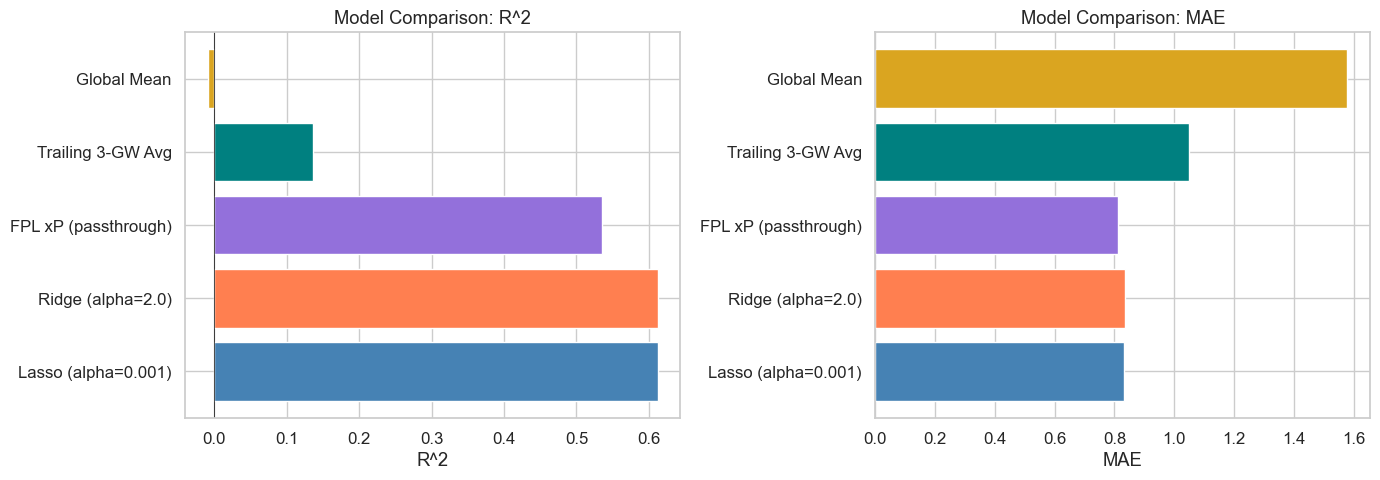

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["steelblue", "coral", "mediumpurple", "teal", "goldenrod"]

axes[0].barh(results_df["Model"], results_df["R^2"], color=colors[:len(results_df)])
axes[0].set_xlabel("R^2")
axes[0].set_title("Model Comparison: R^2")
axes[0].axvline(0, color="black", linewidth=0.5)

axes[1].barh(results_df["Model"], results_df["MAE"], color=colors[:len(results_df)])
axes[1].set_xlabel("MAE")
axes[1].set_title("Model Comparison: MAE")

plt.tight_layout()
plt.show()

It is also interesting to see which features survive Lasso's regularization. This may be helpful for us to implement better preprocessing/cleaning.

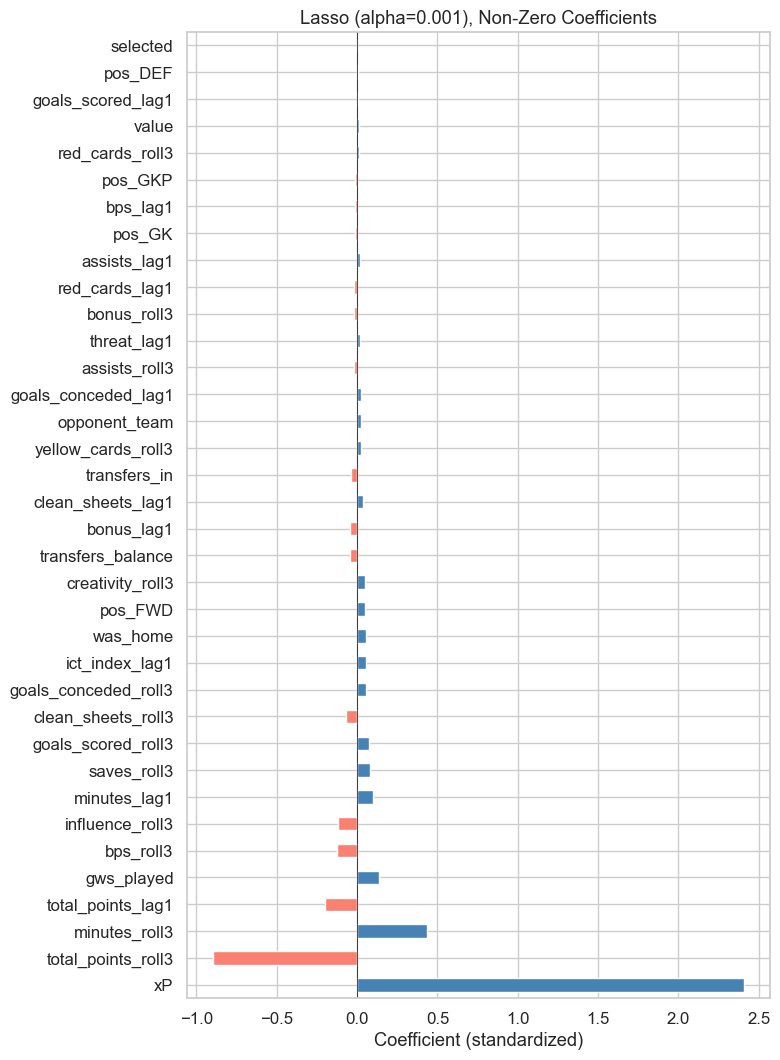

36 / 44 features retained


In [50]:
coef_series = pd.Series(best_model_l.coef_, index=FEATURE_COLS)
nonzero = coef_series[coef_series != 0].sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, max(4, len(nonzero) * 0.3)))
nonzero.plot.barh(ax=ax, color=["steelblue" if v > 0 else "salmon" for v in nonzero])
ax.set_xlabel("Coefficient (standardized)")
ax.set_title(f"Lasso (alpha={best_alpha_l}), Non-Zero Coefficients")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"{len(nonzero)} / {len(FEATURE_COLS)} features retained")

### Summary + Next Steps

- As noted earlier, the target is heavily zero-inflated, which makes even simple baselines haed to beat when comparing on aggregate metrics. Ideally we might change our data preprocessing to adjust for this.
- We notice that FPL's own xP is a strong baseline to go off of. Ridge/Lasso did not meaningfully improve on it, however this might simply be a reflection of the inherent variance in football (soccer) outcomes, not issues with modeling.
- In line with the previous bullet, we expect our R^2 values to be relatively low in absolute terms, since the variance in weekly player performance is domanited by match events that likely no feature set can predict.
- The ICT features (influence, creativity, threat, ict_index, bps, minutes) show high multicollinearity, so this likely leads us to perform PCA.
- Lasso's feature selection revealed that some of our 44 features are simply noise for all intents and purposes of this project, something to consider for upgrading our preprocessing steps.